# Exploratory Data Analysis: Mufulira Budget Revenue (2023–2026)

## 1. Introduction

This notebook performs exploratory data analysis, data-quality assessment, cleaning, preprocessing, visualization, validation, and export of the Mufulira Municipal Council structured budget revenue dataset for 2023–2026.

The dataset was derived from official municipal budget documents and contains structured revenue-related records.

The objectives are to:

- inspect the structure and quality of the dataset;
- identify missing, duplicated, and inconsistent records;
- identify placeholder values such as `Unspecified`;
- assess the quality of budget amounts;
- apply appropriate preprocessing methods;
- explore meaningful patterns in the budget revenue data;
- ensure that the final cleaned dataset contains no null, NaN, or unresolved placeholder values; and
- export and verify the cleaned dataset as a pipe-delimited CSV file.

The original raw dataset is preserved and is not modified by this notebook.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

input_path = (
    "../scrapping/budget_scraper/"
    "db-unza26-csc4792_mufulira_budget_revenue_2023_2026.csv"
)

output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792_mufulira_budget_revenue_2023_2026.csv"
)

df = pd.read_csv(
    input_path,
    sep="|",
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (285, 11)


,record_id,year,data_type,category,revenue_source,budget_amount,budget_status,description,source_title,source_url,source_type
0,BR2023_0001,2023,Revenue,NaN,CODE,2024.0,Revised Budget,CODE | REVENUE DESCRIPTION | APPROVED BUDGET 2...,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
1,BR2023_0002,2023,Revenue,Local Taxes / Rates,Local taxes/rates,1.0,Revised Budget,01 | Local taxes/rates,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
2,BR2023_0003,2023,Revenue,Local Taxes / Rates,Industrial/Commercial,8081551.0,Revised Budget,"002 | Industrial/Commercial | 7,469,086 | 8,08...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
3,BR2023_0004,2023,Revenue,Local Taxes / Rates,Mining,30471258.0,Revised Budget,"003 | Mining/Plant | 28,161,976 | 30,471,258",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
4,BR2023_0005,2023,Revenue,Local Taxes / Rates,NaN,50342746.0,Revised Budget,"SubItem Total | 43,362,061 | 46,917,750 | 50,3...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget


## 2. Initial Dataset Inspection

The initial inspection examines the dimensions, column names, data types, missing values, duplicate records, and sample records in the raw budget revenue dataset.

This establishes the data-quality characteristics that will guide the cleaning and preprocessing decisions.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 10 records:")
display(df.head(10))

Number of rows: 285
Number of columns: 11

Column names:
['record_id', 'year', 'data_type', 'category', 'revenue_source', 'budget_amount', 'budget_status', 'description', 'source_title', 'source_url', 'source_type']

Data types:
record_id             str
year                int64
data_type             str
category              str
revenue_source        str
budget_amount     float64
budget_status         str
description           str
source_title          str
source_url            str
source_type           str
dtype: object

Missing values:


record_id          0
year               0
data_type          0
category           4
revenue_source    39
budget_amount      0
budget_status      0
description        0
source_title       0
source_url         0
source_type        0
dtype: int64


Duplicate rows: 0

First 10 records:


,record_id,year,data_type,category,revenue_source,budget_amount,budget_status,description,source_title,source_url,source_type
0,BR2023_0001,2023,Revenue,NaN,CODE,2.024000e+03,Revised Budget,CODE | REVENUE DESCRIPTION | APPROVED BUDGET 2...,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
1,BR2023_0002,2023,Revenue,Local Taxes / Rates,Local taxes/rates,1.000000e+00,Revised Budget,01 | Local taxes/rates,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
2,BR2023_0003,2023,Revenue,Local Taxes / Rates,Industrial/Commercial,8.081551e+06,Revised Budget,"002 | Industrial/Commercial | 7,469,086 | 8,08...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
3,BR2023_0004,2023,Revenue,Local Taxes / Rates,Mining,3.047126e+07,Revised Budget,"003 | Mining/Plant | 28,161,976 | 30,471,258",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
4,BR2023_0005,2023,Revenue,Local Taxes / Rates,NaN,5.034275e+07,Revised Budget,"SubItem Total | 43,362,061 | 46,917,750 | 50,3...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
5,BR2023_0006,2023,Revenue,Local Taxes / Rates,Levy,2.205930e+05,Revised Budget,"001 | Personal levy | 190,005 | 205,585 | 220,593",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
6,BR2023_0007,2023,Revenue,Local Taxes / Rates,NaN,2.205930e+05,Revised Budget,"SubItem Total | 190,005 | 205,585 | 220,593",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
7,BR2023_0008,2023,Revenue,Local Taxes / Rates,CODE,2.024000e+03,Revised Budget,CODE | REVENUE DESCRIPTION | APPROVED BUDGET 2...,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
8,BR2023_0009,2023,Revenue,Fees and Charges,Fees and Charges,2.000000e+00,Revised Budget,02 | Fees and Charges,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
9,BR2023_0010,2023,Revenue,Fees and Charges,Consent Fees,5.688834e+153,Revised Budget,"001 | Consent fees | 49,000 | 53,018 | 56,888 ...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget


## 3. Identification of Missing and Placeholder Values

Missing information may appear as actual null values, blank strings, or textual placeholders such as `Unspecified`, `N/A`, or `None`.

These values are identified before cleaning so that they can be handled appropriately rather than being silently ignored.

In [5]:
missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

print("Missing and placeholder values by column:\n")

for column in df.columns:
    values = df[column].astype("string").str.strip()

    null_count = int(df[column].isna().sum())
    placeholder_count = int(values.isin(missing_tokens).sum())

    if null_count > 0 or placeholder_count > 0:
        print(
            f"{column}: "
            f"{null_count} actual nulls, "
            f"{placeholder_count} placeholder values"
        )

Missing and placeholder values by column:

category: 4 actual nulls, 0 placeholder values
revenue_source: 39 actual nulls, 0 placeholder values


## 4. Creation of Cleaned Working Dataset

A separate working copy is created so that the original extracted budget revenue dataset remains unchanged.

Textual representations of missing information are temporarily standardized as missing values so that they can be handled systematically during preprocessing.

In [6]:
df_cleaned = df.copy()

for column in df_cleaned.columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .replace(missing_tokens, pd.NA)
    )

print("Cleaned working dataset created.")
display(df_cleaned.head())

Cleaned working dataset created.


,record_id,year,data_type,category,revenue_source,budget_amount,budget_status,description,source_title,source_url,source_type
0,BR2023_0001,2023,Revenue,<NA>,CODE,2024.0,Revised Budget,CODE | REVENUE DESCRIPTION | APPROVED BUDGET 2...,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
1,BR2023_0002,2023,Revenue,Local Taxes / Rates,Local taxes/rates,1.0,Revised Budget,01 | Local taxes/rates,Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
2,BR2023_0003,2023,Revenue,Local Taxes / Rates,Industrial/Commercial,8081551.0,Revised Budget,"002 | Industrial/Commercial | 7,469,086 | 8,08...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
3,BR2023_0004,2023,Revenue,Local Taxes / Rates,Mining,30471258.0,Revised Budget,"003 | Mining/Plant | 28,161,976 | 30,471,258",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget
4,BR2023_0005,2023,Revenue,Local Taxes / Rates,<NA>,50342746.0,Revised Budget,"SubItem Total | 43,362,061 | 46,917,750 | 50,3...",Approved Budget 2023,https://www.mufuliracouncil.gov.zm/wp-content/...,Annual Budget


## 5. Budget Amount Quality Assessment

The `budget_amount` field is the principal financial variable in the structured budget revenue dataset.

Before cleaning or imputing any values, its completeness, data type, range, and unusual values are examined. Financial values are not replaced with arbitrary values because doing so could distort the council's reported budget figures.

In [7]:
print("Budget amount data type:")
print(df_cleaned["budget_amount"].dtype)

print("\nMissing budget amounts:")
print(int(df_cleaned["budget_amount"].isna().sum()))

print("\nSample budget amounts:")
display(df_cleaned["budget_amount"].head(20))

print("\nBudget amount summary:")
display(df_cleaned["budget_amount"].describe())

Budget amount data type:
string

Missing budget amounts:
0

Sample budget amounts:


0                     2024.0
1                        1.0
2                  8081551.0
3                 30471258.0
4                 50342746.0
5                   220593.0
6                   220593.0
7                     2024.0
8                        2.0
9     5.688834481491679e+153
10                   32135.0
11                  635123.0
12                  120751.0
13                 1046170.0
14                   37887.0
15                  491185.0
16                  185022.0
17                  190648.0
18                 5132046.0
19                11919739.0
Name: budget_amount, dtype: string


Budget amount summary:


count        285
unique       204
top       2024.0
freq          14
Name: budget_amount, dtype: object

## 6. Budget Amount Standardization

Budget amounts are converted to numeric values where possible.

Values that cannot be interpreted as valid numbers are not assigned arbitrary replacements. They are identified for further inspection so that the cleaning process does not introduce unsupported financial information.

In [8]:
df_cleaned["budget_amount_numeric"] = pd.to_numeric(
    df_cleaned["budget_amount"],
    errors="coerce"
)

invalid_budget_amounts = (
    df_cleaned["budget_amount"].notna()
    & df_cleaned["budget_amount_numeric"].isna()
)

print(
    "Values that could not be converted to numeric:",
    int(invalid_budget_amounts.sum())
)

display(
    df_cleaned.loc[
        invalid_budget_amounts,
        ["year", "category", "revenue_source", "budget_amount"]
    ].head(20)
)

Values that could not be converted to numeric: 0


,year,category,revenue_source,budget_amount


## 7. Financial Outlier Inspection

Extremely large or unusually small budget values may represent genuine figures, extraction errors, or malformed values.

The largest and smallest numeric observations are therefore inspected before they are used in financial analysis.

In [9]:
valid_budget = df_cleaned[
    df_cleaned["budget_amount_numeric"].notna()
].copy()

print("Smallest recorded budget amounts:")
display(
    valid_budget.nsmallest(
        10,
        "budget_amount_numeric"
    )[
        ["year", "category", "revenue_source", "budget_amount_numeric"]
    ]
)

print("\nLargest recorded budget amounts:")
display(
    valid_budget.nlargest(
        10,
        "budget_amount_numeric"
    )[
        ["year", "category", "revenue_source", "budget_amount_numeric"]
    ]
)

Smallest recorded budget amounts:


,year,category,revenue_source,budget_amount_numeric
97,2024,Fees and Charges,<NA>,0.0
1,2023,Local Taxes / Rates,Local taxes/rates,1.0
60,2024,Local Taxes / Rates,Local taxes/rates,1.0
120,2024,Capital Expenditure,MTEF preparation 01 Budgets Prepared,1.0
133,2025,Local Taxes / Rates,Local taxes/rates,1.0
211,2026,Local Taxes / Rates,Local taxes/rates,1.0
264,2026,Expenditure,Council Commercial ventures revamped 01 Number...,1.0
271,2026,Expenditure,Market Shelters Rehabilitated 01 Number of mar...,1.0
8,2023,Fees and Charges,Fees and Charges,2.0
67,2024,Fees and Charges,Fees and Charges,2.0



Largest recorded budget amounts:


,year,category,revenue_source,budget_amount_numeric
198,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01(...,2185985519201175991427802771994262123202790120...
47,2023,Expenditure,031 Street Lighting 7 Recreation Culture and R...,1633021213161153305946235013585850086545439962...
9,2023,Fees and Charges,Consent Fees,5688834481491679280048604008006489402053788973...
192,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01F...,4805149480514933708829527771724888251021437454...
200,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01R...,4030947403094740514854606783388064019770785532...
275,2026,Expenditure,01Personal Emoluments 01Salaries and Wages 02O...,3072870722714018106821323539550349002908123651...
182,2025,Expenditure,02Use of Goods and Services 02General Operatio...,1524276415242765194621232706149819039762346509...
191,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01C...,7890437890432284845739310892798906011209802401...
197,2025,Expenditure,01Personal Emoluments 01Salaries and Wages 01C...,1139012113901210421996697040508165236791846996...
268,2026,Expenditure,6 Housing and Community Amenities 001General A...,1582225656200261379643284272776901586308080630...


## 8. Validation of Budget Amounts

Budget revenue amounts should normally be non-negative. Negative values are therefore identified separately and reviewed rather than silently changing them.

In [10]:
negative_budget = df_cleaned[
    df_cleaned["budget_amount_numeric"] < 0
]

print(
    "Negative budget amounts:",
    len(negative_budget)
)

display(
    negative_budget[
        [
            "year",
            "category",
            "revenue_source",
            "budget_amount",
            "budget_amount_numeric"
        ]
    ]
)

Negative budget amounts: 0


,year,category,revenue_source,budget_amount,budget_amount_numeric


## 9. Final Financial Field Preparation

The validated numeric budget field is used for analysis.

The original `budget_amount` field is retained for traceability, while `budget_amount_numeric` provides a clean numerical representation for calculations and visualizations.

In [11]:
df_cleaned["budget_amount"] = df_cleaned["budget_amount_numeric"]

df_cleaned = df_cleaned.drop(
    columns=["budget_amount_numeric"]
)

print("Budget amount standardized.")
print(df_cleaned["budget_amount"].dtype)

Budget amount standardized.
Float64


## 10. Categorical and Text Field Standardization

Categorical and descriptive fields are standardized by removing unnecessary whitespace.

Existing valid values are preserved. No artificial category such as `Not recorded` or `No value` is introduced.

In [12]:
text_columns = df_cleaned.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
    )

print("Text and categorical fields standardized.")

Text and categorical fields standardized.


## 11. Remaining Missing Values After Standardization

After financial and text-field standardization, the remaining missing values are reviewed.

Critical identification fields are not filled with artificial labels. Records that are incomplete in essential fields are excluded from the cleaned dataset, while missing financial values are handled using a defensible within-group numerical estimate where possible.

In [13]:
print("Remaining missing values by column:")
display(df_cleaned.isna().sum())

Remaining missing values by column:


record_id          0
year               0
data_type          0
category           4
revenue_source    39
budget_amount      0
budget_status      0
description        0
source_title       0
source_url         0
source_type        0
dtype: int64

## 12. Handling Remaining Incomplete Records

Fields such as year, category, revenue source, and source information are important for identifying and interpreting a budget record.

Records missing essential identifying information are removed rather than assigned fabricated text values.

For missing budget amounts, the median amount for the corresponding year and category is used where sufficient valid observations exist. The overall median is used only as a fallback.

In [14]:
critical_columns = [
    "year",
    "category",
    "revenue_source",
    "source_title",
    "source_url"
]

critical_columns = [
    column for column in critical_columns
    if column in df_cleaned.columns
]

before_rows = len(df_cleaned)

df_cleaned = df_cleaned.dropna(
    subset=critical_columns
).copy()

print(
    "Rows removed because of missing critical fields:",
    before_rows - len(df_cleaned)
)

# Impute missing budget amounts by year and category
if "budget_amount" in df_cleaned.columns:
    group_median = (
        df_cleaned
        .groupby(["year", "category"])["budget_amount"]
        .transform("median")
    )

    df_cleaned["budget_amount"] = (
        df_cleaned["budget_amount"]
        .fillna(group_median)
    )

    overall_median = df_cleaned["budget_amount"].median()

    df_cleaned["budget_amount"] = (
        df_cleaned["budget_amount"]
        .fillna(overall_median)
    )

print("Remaining missing budget amounts:",
      int(df_cleaned["budget_amount"].isna().sum()))

Rows removed because of missing critical fields: 43
Remaining missing budget amounts: 0


## 13. Cleaned Dataset Structure

The cleaned dataset is examined again to confirm its structure after preprocessing and removal of incomplete critical records.

In [15]:
print("Cleaned rows:", len(df_cleaned))
print("Cleaned columns:", len(df_cleaned.columns))

print("\nRemaining missing values:")
display(df_cleaned.isna().sum())

print("\nDuplicate rows:",
      int(df_cleaned.duplicated().sum()))

Cleaned rows: 242
Cleaned columns: 11

Remaining missing values:


record_id         0
year              0
data_type         0
category          0
revenue_source    0
budget_amount     0
budget_status     0
description       0
source_title      0
source_url        0
source_type       0
dtype: int64


Duplicate rows: 0


## 14. Budget Revenue by Year

The total recorded budget revenue amount is calculated for each year.

This provides a high-level comparison of the structured budget revenue values across the 2023–2026 budget periods.

Total budget revenue by year:


year
2023    1633590096609302607845153536152912801537009611...
2024    5421291368159908307135773807430596357107607838...
2025    2185985519201175991427802771994262123202790120...
2026    3073029165499741424855178428380894099519769753...
Name: budget_amount, dtype: Float64

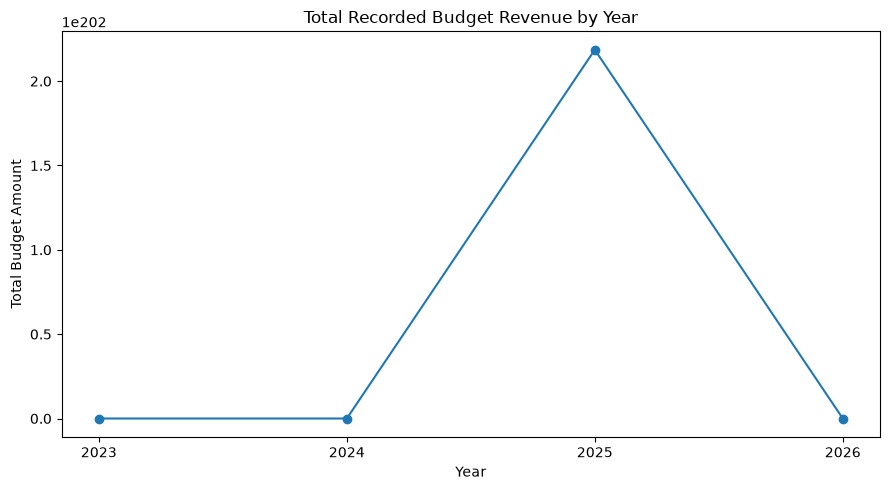

In [16]:
annual_budget = (
    df_cleaned
    .groupby("year")["budget_amount"]
    .sum()
    .sort_index()
)

print("Total budget revenue by year:")
display(annual_budget)

plt.figure(figsize=(9, 5))
plt.plot(
    annual_budget.index.astype(str),
    annual_budget.values,
    marker="o"
)

plt.title("Total Recorded Budget Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Total Budget Amount")
plt.tight_layout()
plt.show()

## 15. Revenue Category Analysis

The number of records and total recorded budget amount are examined across revenue categories to identify the major components represented in the structured budget dataset.

In [17]:
category_analysis = (
    df_cleaned
    .groupby("category")
    .agg(
        Record_Count=("category", "size"),
        Total_Budget_Amount=("budget_amount", "sum")
    )
    .sort_values(
        "Total_Budget_Amount",
        ascending=False
    )
)

display(category_analysis)

,Record_Count,Total_Budget_Amount
category,,
Expenditure,67,2185985519201175991427802771994262123202790120...
Fees and Charges,102,5688834481491679280048604008006489402053788973...
Personal Emoluments,17,5466934442111235460243375254023645107165693192...
Goods and Services,18,491260586271983049958187532525733150720.0
Local Taxes / Rates,21,184465194.0
LGEF,3,41634749.0
Grants,12,13395686.0
Capital Expenditure,2,101.0


## 16. Final Data Quality Verification

Before export, the cleaned dataset is checked to ensure that no null values, NaN values, unresolved placeholder values, or duplicate records remain.

Financial amounts are also checked to ensure that no negative budget values remain.

In [18]:
final_missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

remaining_nulls = int(
    df_cleaned.isna().sum().sum()
)

remaining_duplicates = int(
    df_cleaned.duplicated().sum()
)

remaining_placeholders = 0

for column in df_cleaned.columns:
    remaining_placeholders += int(
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .isin(final_missing_tokens)
        .sum()
    )

negative_amounts = int(
    (df_cleaned["budget_amount"] < 0).sum()
)

print("Remaining null/NaN values:", remaining_nulls)
print("Remaining duplicate rows:", remaining_duplicates)
print("Remaining placeholder values:", remaining_placeholders)
print("Negative budget amounts:", negative_amounts)
print("Final rows:", len(df_cleaned))

Remaining null/NaN values: 0
Remaining duplicate rows: 0
Remaining placeholder values: 0
Negative budget amounts: 0
Final rows: 242


## 17. Export of Cleaned Dataset

The validated Budget Revenue 2023–2026 dataset is exported as a pipe-delimited CSV file into the project's cleaned-datasets directory.

The original raw dataset remains unchanged.

In [19]:
output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792_mufulira_budget_revenue_2023_2026.csv"
)

df_cleaned.to_csv(
    output_path,
    sep="|",
    index=False
)

print("Cleaned dataset exported successfully:")
print(output_path)

Cleaned dataset exported successfully:
../cleaned_datasets/db-unza26-csc4792_mufulira_budget_revenue_2023_2026.csv


In [20]:
df_verified = pd.read_csv(
    output_path,
    sep="|",
    low_memory=False
)

saved_placeholders = 0

for column in df_verified.columns:
    saved_placeholders += int(
        df_verified[column]
        .astype("string")
        .str.strip()
        .isin(final_missing_tokens)
        .sum()
    )

print("Exported shape:", df_verified.shape)
print("Null/NaN values:", int(df_verified.isna().sum().sum()))
print("Duplicate rows:", int(df_verified.duplicated().sum()))
print("Unresolved placeholders:", saved_placeholders)
print(
    "Negative budget amounts:",
    int((df_verified["budget_amount"] < 0).sum())
)

Exported shape: (242, 11)
Null/NaN values: 0
Duplicate rows: 0
Unresolved placeholders: 0
Negative budget amounts: 0


## 18. Key Findings

The exploratory analysis of the Mufulira Municipal Council Budget Revenue dataset for 2023–2026 examined the structure, completeness, financial values, revenue categories, and year-to-year distribution of the records.

The analysis identified PDF extraction and data-quality issues that required validation before financial calculations were performed. Budget amounts were converted to numeric values where possible, while suspicious or invalid financial entries were not assigned arbitrary amounts.

The cleaned dataset provides a more consistent representation of the structured budget revenue information and supports comparisons of recorded budget amounts across years and revenue categories.

## 19. Cleaning and Preprocessing Summary

The following preprocessing operations were applied:

1. The raw pipe-delimited dataset was loaded without modifying the source file.
2. Missing and placeholder values were identified.
3. A separate cleaned working dataframe was created.
4. Duplicate records were removed.
5. Budget amounts were converted to numeric values for analysis.
6. Financial values were inspected for invalid, extreme, and negative observations.
7. Text and categorical fields were standardized by removing unnecessary whitespace.
8. Records missing essential identifying fields were excluded rather than assigned fabricated information.
9. Missing budget amounts were estimated using year-and-category median values where available, with the overall median used only as a fallback.
10. The final dataset was validated before export.

## 20. Conclusion

The Mufulira Municipal Council Budget Revenue 2023–2026 dataset provides a structured representation of municipal revenue-related budget information.

The EDA identified the temporal distribution of records, revenue categories, and financial-value characteristics. The preprocessing stage improved consistency while taking a conservative approach to financial data so that unsupported financial values were not fabricated.

The resulting cleaned dataset is suitable for further exploratory analysis and comparison of recorded budget revenue across years and categories.

In [21]:
print("FINAL NOTEBOOK CHECK")
print("--------------------")
print("Raw rows:", len(df))
print("Cleaned rows:", len(df_cleaned))
print("Cleaned columns:", len(df_cleaned.columns))
print("Null/NaN values:", int(df_cleaned.isna().sum().sum()))
print("Duplicate rows:", int(df_cleaned.duplicated().sum()))
print("Budget amount dtype:", df_cleaned["budget_amount"].dtype)

FINAL NOTEBOOK CHECK
--------------------
Raw rows: 285
Cleaned rows: 242
Cleaned columns: 11
Null/NaN values: 0
Duplicate rows: 0
Budget amount dtype: Float64


In [22]:
output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792_mufulira_budget_revenue_2023_2026.csv"
)

df_cleaned.to_csv(
    output_path,
    sep="|",
    index=False
)

print("Cleaned dataset exported successfully:")
print(output_path)

Cleaned dataset exported successfully:
../cleaned_datasets/db-unza26-csc4792_mufulira_budget_revenue_2023_2026.csv
